### Descargar dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ananthu017/emotion-detection-fer")

print("Path to dataset files:", path)

c:\Users\tiny\miniconda3\envs\mlops-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\tiny\.cache\kagglehub\datasets\ananthu017\emotion-detection-fer\versions\1


### Analizando un poco el dataset

In [3]:
import os

data = os.listdir(path)
print(f"Total folders in this Dataset: {len(data)}")
print(f"Files in this Dataset: {data}")

# Define emotions
emotions = ['angry', 'disgusted', 'fearful', 'neutral', 'surprised']

Total folders in this Dataset: 2
Files in this Dataset: ['test', 'train']


Total training images: 28709


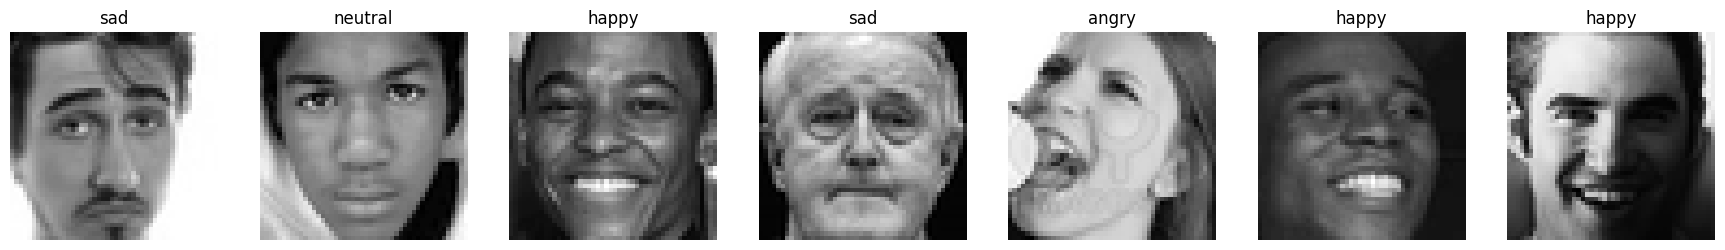

Image size (W x H): (48, 48)


In [4]:
from glob import glob
import matplotlib.pyplot as plt
from PIL import Image
import random

train_dir = os.path.join(path, "train")

example_path = glob(os.path.join(path, "train", "*", "*.png"))
print("Total training images:", len(example_path))

fig, axes = plt.subplots(1, 7, figsize=(22,8))
for ax in axes:
    img_path = random.choice(example_path)
    label = img_path.split(os.sep)[-2]  
    img = Image.open(img_path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.show()
print("Image size (W x H):", img.size)

In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/train",
    labels="inferred",
    class_names=emotions,
    label_mode="categorical",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=64,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/train",
    labels="inferred",
    class_names=emotions,
    label_mode="categorical",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=64,
    shuffle=False
)

Found 16664 files belonging to 5 classes.
Found 16664 files belonging to 5 classes.


### Definir el modelo de redes neuronales convolucionales

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import os

def create_cnn_model(input_shape=(48, 48, 1), num_classes=5):
    """
    Crea una CNN con tres capas de convolución.

    Se utiliza 16->32->64 filtros en las capas de convolución, para no hacer 
    el modelo demasiado pesado, sin embargo, conservando una buena capacidad
    de aprendizaje. A diferencia de 32->64->128 que es más común, pero más pesado.
    (Nuestras maquinas tienen recursos limitados).

    Dropout se añade para evitar overfitting solo en la tercera capa, ya que el 
    conjunto de datos no es muy pequeño. Para conjuntos de datos más pequeños 
    se recomienda añadir Dropout en las primeras capas también.
    """
    model = Sequential([

        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Conv2D(128, (3, 3), activation='relu'),
        Dropout(0.25),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

In [7]:
import mlflow
import mlflow.tensorflow
from tensorflow.keras.losses import CategoricalCrossentropy

def train_cnn():
    """
    Entrena la CNN y registra en MLflow.
    """
    mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "http://localhost:5000"))
    mlflow.set_experiment("image_classification_cnn")
    mlflow.tensorflow.autolog()
    
    with mlflow.start_run():
        model = create_cnn_model()
        print('compiling...')
        model.compile(
            optimizer='adam',
            loss=CategoricalCrossentropy(),
            metrics=['accuracy']
        )
        print('training...')
        model.fit(train_ds, validation_data=val_ds, epochs=20)
        
        # Log parámetros
        mlflow.log_param("optimizer", "adam")
        mlflow.log_param("num_conv_layers", 3)
        mlflow.log_param("num_classes", 3)
        
        print('logging model to mlflow...')
        mlflow.tensorflow.log_model(model, "model")
        
        return model

model = train_cnn()


c:\Users\tiny\miniconda3\envs\mlops-env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


compiling...
training...


Epoch 1/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.2739 - loss: 3.5639

261/261 ━━━━━━━━━━━━━━━━━━━━ 214s 803ms/step - accuracy: 0.2907 - loss: 1.9147 - val_accuracy: 0.3301 - val_loss: 1.4441
Epoch 2/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 710ms/step - accuracy: 0.3243 - loss: 1.4525

261/261 ━━━━━━━━━━━━━━━━━━━━ 240s 918ms/step - accuracy: 0.3493 - loss: 1.4262 - val_accuracy: 0.4453 - val_loss: 1.3466
Epoch 3/20
261/261 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.3883 - loss: 1.3892

...

261/261 ━━━━━━━━━━━━━━━━━━━━ 219s 840ms/step - accuracy: 0.6155 - loss: 0.9201 - val_accuracy: 0.7046 - val_loss: 0.7780
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step


2025/11/18 11:56:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/18 11:56:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


logging model to mlflow...


2025/11/18 11:56:59 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2025/11/18 11:57:18 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run lyrical-gnat-308 at: http://localhost:5000/#/experiments/596809579084997410/runs/863c4b014c254e948d160aa037815f00
🧪 View experiment at: http://localhost:5000/#/experiments/596809579084997410


In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    path + "/test",
    labels="inferred",
    class_names=emotions,
    label_mode="categorical",
    color_mode="grayscale",
    image_size=(48, 48),
    batch_size=64,
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_ds)
print('\nTest accuracy:', test_acc)
print('\nTest lost', test_loss)

Found 4157 files belonging to 5 classes.
65/65 ━━━━━━━━━━━━━━━━━━━━ 48s 733ms/step - accuracy: 0.5725 - loss: 1.0502

Test accuracy: 0.5725282430648804

Test lost 1.050244927406311


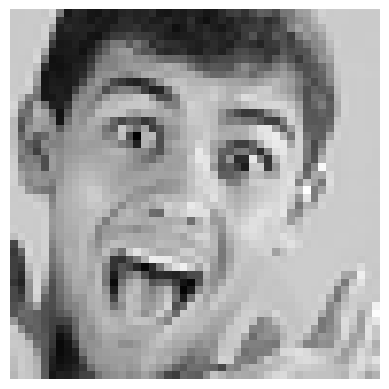

Test image path: C:\Users\tiny\.cache\kagglehub\datasets\ananthu017\emotion-detection-fer\versions\1\test\happy\im1192.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Predicted emotion: surprised
angry: 0.13%
disgusted: 0.00%
fearful: 4.48%
neutral: 0.09%
surprised: 95.31%


'../test/im1192.png'

In [27]:
test_path = glob(os.path.join(path, "test", "*", "*.png"))
test_image = random.choice(test_path)
img = Image.open(test_image)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()
print("Test image path:", test_image)
img = img.convert("L")
img = img.resize((48, 48))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis
predictions = model.predict(img_array)
predicted_class = emotions[tf.argmax(predictions[0])]
print("Predicted emotion:", predicted_class)
#map emotions to probabilities
for i, emotion in enumerate(emotions):
    print(f"{emotion}: {predictions[0][i]*100:.2f}%")

#copy the image to ../test 
import shutil
shutil.copy(test_image, "../test/")